#### IMport Libraries

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score


#### Import excel file(Only Numerical data)

In [42]:
import pandas as pd

pd.ExcelFile('/content/EastWestAirlines.xlsx').sheet_names


['Description', 'data']

In [56]:
df = pd.read_excel(
    '/content/EastWestAirlines.xlsx',
    sheet_name='data',

)


In [57]:
# Only Numerical columns
df_numeric = df.select_dtypes(include=['int64', 'float64'])
df_numeric.head()


,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


#### Check Missing Values

In [59]:
print("Missing values in each column:")
print(df_numeric.isnull().sum())


Missing values in each column:
ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64


In [58]:
# handling missing values
df_numeric = df_numeric.fillna(df_numeric.mean())

print("Missing values handled")
print(df_numeric.isnull().sum())


Missing values handled
ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64


#### Exploratory data analysis

In [60]:
# summary
print("Statistical Summary:")
print(df_numeric.describe())


Statistical Summary:
               ID#       Balance    Qual_miles    cc1_miles    cc2_miles  \
count  3999.000000  3.999000e+03   3999.000000  3999.000000  3999.000000   
mean   2014.819455  7.360133e+04    144.114529     2.059515     1.014504   
std    1160.764358  1.007757e+05    773.663804     1.376919     0.147650   
min       1.000000  0.000000e+00      0.000000     1.000000     1.000000   
25%    1010.500000  1.852750e+04      0.000000     1.000000     1.000000   
50%    2016.000000  4.309700e+04      0.000000     1.000000     1.000000   
75%    3020.500000  9.240400e+04      0.000000     3.000000     1.000000   
max    4021.000000  1.704838e+06  11148.000000     5.000000     3.000000   

         cc3_miles    Bonus_miles  Bonus_trans  Flight_miles_12mo  \
count  3999.000000    3999.000000   3999.00000        3999.000000   
mean      1.012253   17144.846212     11.60190         460.055764   
std       0.195241   24150.967826      9.60381        1400.209171   
min       1.000000

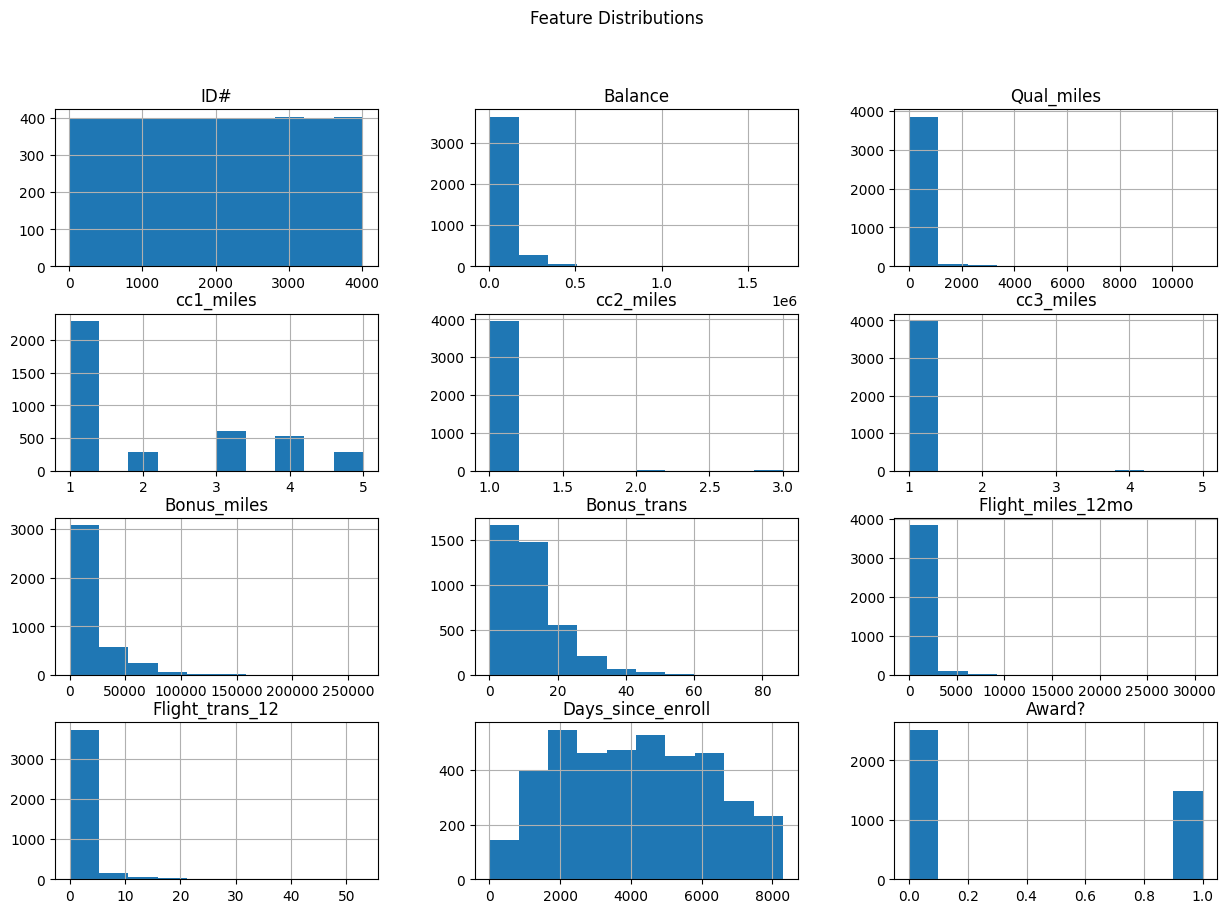

In [61]:
# Distribution Plots
df_numeric.hist(figsize=(15,10))
plt.suptitle("Feature Distributions")
plt.show()


In [62]:
# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

print("Data scaled successfully")
print("Scaled data shape:", X_scaled.shape)


Data scaled successfully
Scaled data shape: (3999, 12)


#### K-Means Elbow Method

Elbow values (Inertia): [39018.929573862806, 34921.50772657174, 30616.59489562145, 29033.425621185044, 26483.596695961343, 22734.509622722857, 19335.86741380196, 18019.771884004178, 16919.334558690443]


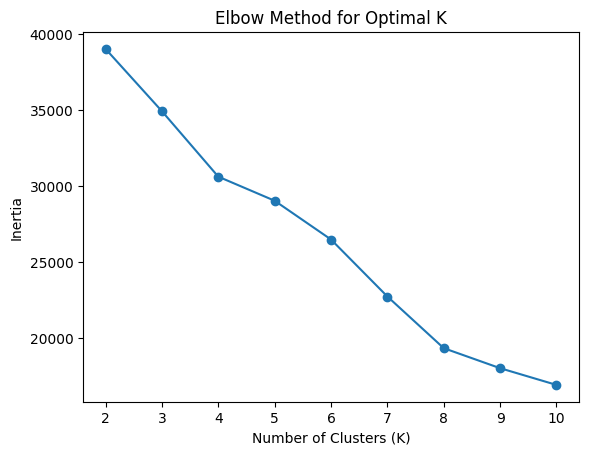

In [64]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

print("Elbow values (Inertia):", inertia)

plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()


#### Apply K-Means Clustering


In [65]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

df_numeric['KMeans_Cluster'] = kmeans_labels

print("K-Means clustering applied")
print(df_numeric['KMeans_Cluster'].value_counts())


K-Means clustering applied
KMeans_Cluster
0    1625
2    1406
1     968
Name: count, dtype: int64


#### K-Means Evaluation (Silhouette Score)

In [66]:
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)

print("Silhouette Score for K-Means:", kmeans_silhouette)


Silhouette Score for K-Means: 0.201891717665419


In [67]:
# Apply DB-Scan Clustering
dbscan = DBSCAN(eps=0.8, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

df_numeric['DBSCAN_Cluster'] = dbscan_labels

print("DBSCAN clustering applied")
print(df_numeric['DBSCAN_Cluster'].value_counts())


DBSCAN clustering applied
DBSCAN_Cluster
 0    2170
 1     889
-1     884
 4      16
 5      10
 6       7
 8       7
 2       6
 3       5
 7       5
Name: count, dtype: int64


In [68]:
# DB-Scan Evaluation (silhouette score)
if len(set(dbscan_labels)) > 1:
    dbscan_silhouette = silhouette_score(X_scaled, dbscan_labels)
    print("Silhouette Score for DBSCAN:", dbscan_silhouette)
else:
    print("DBSCAN produced only one cluster or noise")


Silhouette Score for DBSCAN: -0.011302546565510172


#### Visualization Of Clusters

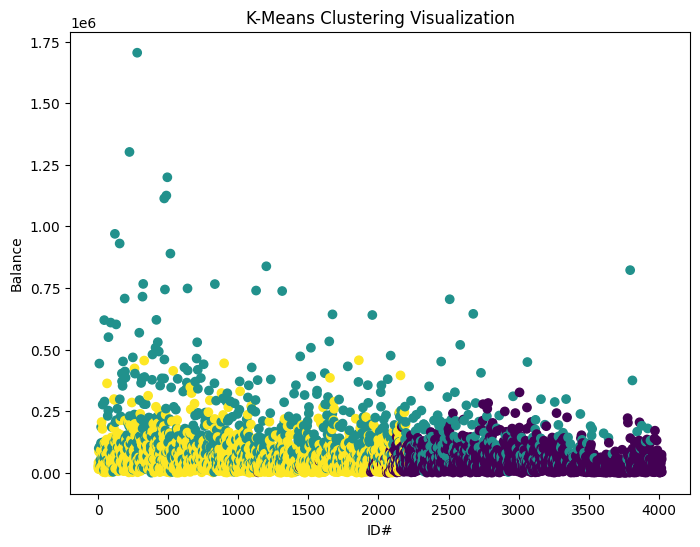

In [76]:
plt.figure(figsize=(8,6))
plt.scatter(
    df_numeric.iloc[:, 0],
    df_numeric.iloc[:, 1],
    c=df_numeric['KMeans_Cluster']
)
plt.xlabel(df_numeric.columns[0])
plt.ylabel(df_numeric.columns[1])
plt.title("K-Means Clustering Visualization")
plt.show()


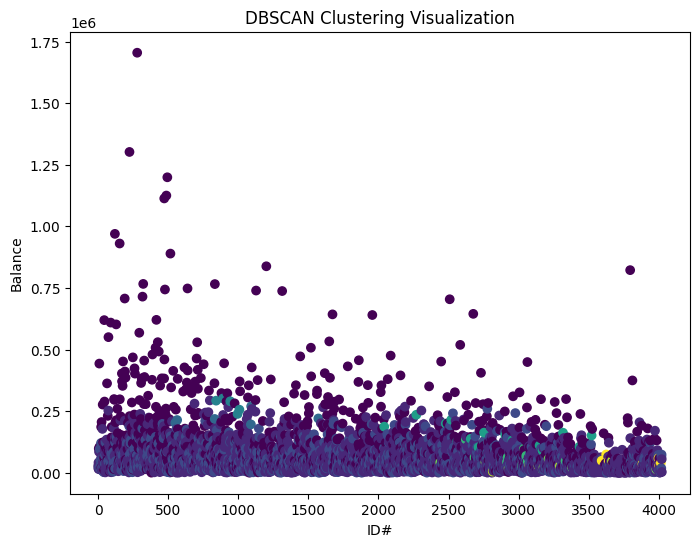

In [83]:
plt.figure(figsize=(8,6))
plt.scatter(
    df_numeric.iloc[:, 0],
    df_numeric.iloc[:, 1],
    c=df_numeric['DBSCAN_Cluster']
)
plt.xlabel(df_numeric.columns[0])
plt.ylabel(df_numeric.columns[1])
plt.title("DBSCAN Clustering Visualization")
plt.show()


#### Evaluation and Performance Metrics

In [ ]:
# K-Means clustering grouped customers into distinct clusters based on similar numerical attributes.
# DBSCAN identified dense regions and noise points, which represent outliers.
# K-Means performed better in terms of silhouette score, while DBSCAN  was effective in detecting anomalies.